In [1]:
import sys
from pathlib import Path

sys.path.insert(0, '../../')
import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

plot_dir = Path('validation_fiber_assignment_ELG')
plot_dir.mkdir(exist_ok=True)
ext = 'pdf'

### Plot of angular upweights

In [ ]:
for tracer in ['ELG_LOPnotqso']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['particle2_angular_upweights', 'particle3_angular_upweights']:
            stats_dir = tools.base_stats_dir
            project = 'full_shape/fiber_assignment_systematics_ELG_LRG1'
            region = 'NGC'
            fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='abacus-hf-dr2-v2-altmtl',
                                    tracer=tracer, region=region, weight='default-FKP', imock=0)
            angular = types.read(fn)
            if 'particle2' in kind:
                angular = angular.get('DD')
                fig, ax = plt.subplots()
                ax.plot(angular.coords('theta'), angular.value(), color='k', label='DD')
                ax.set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
                ax.grid(True)
                ax.legend(frameon=False)
                ax.set_title(f'{tracer} angular upweights in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            elif 'particle3' in kind:
                angular = angular.get('DDD')
                fig, ax = plt.subplots()
                # 2D color map
                X, Y = np.meshgrid(*list(angular.coords().values())[:2])
                Z = angular.value().mean(axis=0)
                pcm = ax.pcolormesh(X, Y, Z, shading='auto')
                fig.colorbar(pcm, ax=ax, label='DDD')
                ax.set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
                ax.set_ylabel(r'$\theta$ [$\mathrm{deg}$]')
                ax.grid(True)
                ax.legend(frameon=False)
                ax.set_title(f'{tracer} angular upweights in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            basename = f'{kind}_{tracer}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()
                

### Comparison of altmtl and "on-the-fly complete" mocks

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics_ELG_tilelocid-LRG0/abacus-hf-dr2-v2-altmtl/mock0/mesh2_spectrum_poles_ELG_LOPnotqso_z0.8-1.1_NGC_weight-default.h5


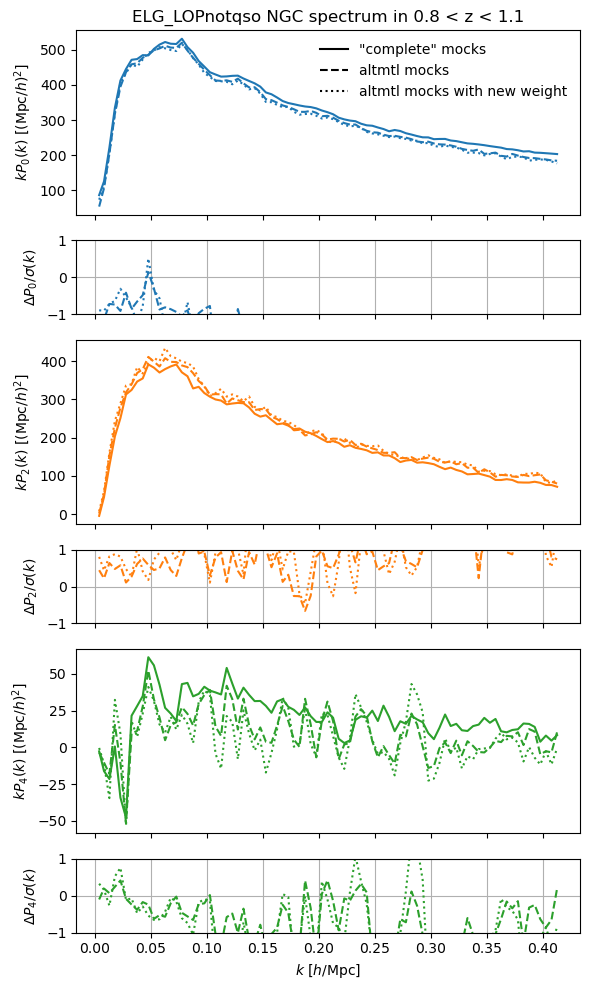

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics_ELG_tilelocid-LRG0/abacus-hf-dr2-v2-altmtl/mock0/mesh2_spectrum_poles_ELG_LOPnotqso_z1.1-1.6_NGC_weight-default.h5


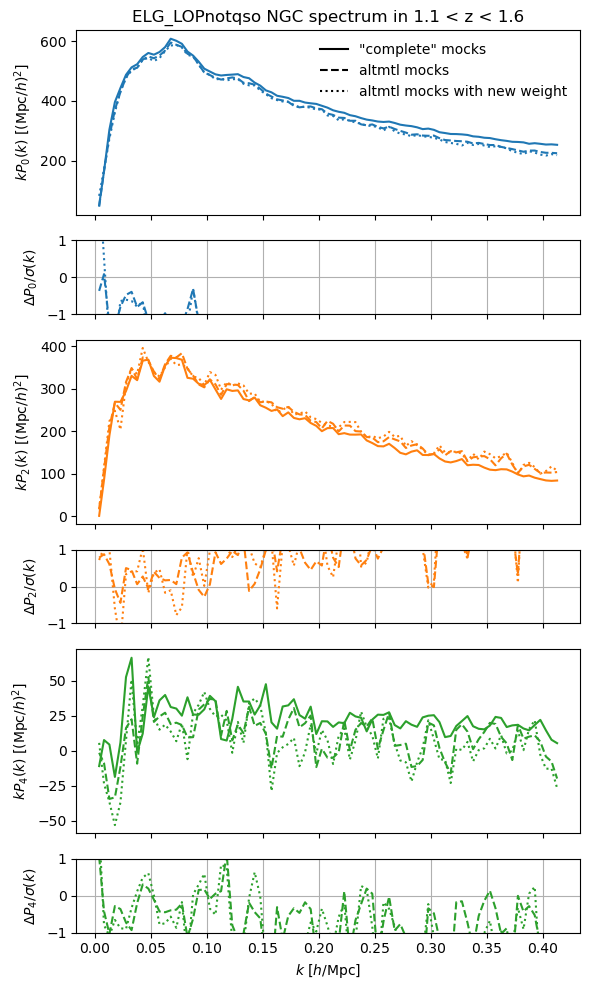

In [5]:
with_auw = True

for tracer in ['ELG_LOPnotqso']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum']:
            stats_dir = tools.base_stats_dir
            region = 'NGC'
            version = 'holi-v3-altmtl'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]

            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
            mean = cov.observable

            nmocks = 2
            version = 'abacus-hf-dr2-v2-altmtl'
            project = 'full_shape/fiber_assignment_systematics'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean = types.mean(mocks).match(mean)

            if with_auw:
                project = 'full_shape/fiber_assignment_systematics_ELG_tilelocid-LRG0'
                fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                          zrange=zrange, region=region, weight='default', basis='sugiyama-diagonal', imock=imock) for imock in range(nmocks)]
                print(fns[0])
                mocks = [types.read(fn) for fn in fns if fn.exists()]
                mean_auw = types.mean(mocks).match(mean)

            project = 'full_shape/fiber_assignment_systematics'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra='complete',
                                      imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean_complete = types.mean(mocks).match(mean)
            nmocks = len(mocks)  # scale error bars

            if 'mesh2' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(mean.ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    if with_auw:
                        pole = mean_auw.get(ell)
                        ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    pole = mean.get(ell)
                    std = cov.at.observable.get(ell).std() # / nmocks**0.5
                    pole_complete = mean_complete.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle='--')
                    if with_auw:
                        pole = mean_auw.get(ell)
                        ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
                if with_auw:
                    ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with new weight')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            elif 'mesh3' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='-')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='--')
                    if with_auw:
                        pole = mean_auw.get(ell)
                        ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle=':')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    #ax.set_ylim(-5e4, 5e4)
                    pole = mean.get(ell)
                    std = cov.at.observable.get(ell).std() #/ nmocks**0.5
                    pole_complete = mean_complete.get(ell)
                    ax.plot(k, (pole.value() - pole_complete.value()) / std, color=color, linestyle='--')
                    if with_auw:
                        pole = mean_auw.get(ell)
                        ax.plot(k, (pole.value() - pole_complete.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
                if with_auw:
                    ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with AUW')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            basename = f'validation_auw_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()